# Laboratorio 3: Deep Learning Desde Cero

Generado por la cátedra de Introducción a la Inteligencia Artificial de la  Licenciatura en Ciencias de la Computación - UNR

Autor: Nicolás Soncini

In [ ]:
from pathlib import Path
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

# Kaggle es un proveedor de datasets (y modelos, y competencias, etc) al igual que huggingface.
import kagglehub

# Tensorflow es un a librería o motor de machine learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
# chequeamos las versiones de las librerias y si tenemos GPU
# (dato de color: la traducción de "library" debería ser biblioteca, y no librería)
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Keras version: 3.10.0


# Parte 1 - Dataset

Utilizaremos el subconjunto "byclass", que separa las clases en:

- Digits: 0-9 (10 classes)
- Uppercase letters: A-Z (26 classes)
- Lowercase letters: a-z (26 classes)

dando un total de 62 clases.  ((TODO: usamos balanced, son 47???))

El dataset EMNIST provee imágenes de 28x28 en escala de grises.

In [ ]:
# Descargamos EMNIST (Extended MNIST)
# Aproximadamente 1.24GB (~45 segundos si Google está de buen humor)
emnist_path = Path(kagglehub.dataset_download("crawford/emnist"))

Using Colab cache for faster access to the 'emnist' dataset.


In [ ]:
for dir in emnist_path.iterdir():
    print(dir)

train_csv = Path(emnist_path) / 'emnist-balanced-train.csv'
test_csv = Path(emnist_path) / 'emnist-balanced-test.csv'
mapping_txt = Path(emnist_path) / 'emnist-balanced-mapping.txt'

/kaggle/input/emnist/emnist-letters-mapping.txt
/kaggle/input/emnist/emnist-letters-test.csv
/kaggle/input/emnist/emnist-mnist-mapping.txt
/kaggle/input/emnist/emnist-digits-train.csv
/kaggle/input/emnist/emnist-bymerge-mapping.txt
/kaggle/input/emnist/emnist-balanced-train.csv
/kaggle/input/emnist/emnist-digits-test.csv
/kaggle/input/emnist/emnist-balanced-test.csv
/kaggle/input/emnist/emnist-mnist-test.csv
/kaggle/input/emnist/emnist-letters-train.csv
/kaggle/input/emnist/emnist-byclass-train.csv
/kaggle/input/emnist/emnist-bymerge-test.csv
/kaggle/input/emnist/emnist-balanced-mapping.txt
/kaggle/input/emnist/emnist-mnist-train.csv
/kaggle/input/emnist/emnist-digits-mapping.txt
/kaggle/input/emnist/emnist-bymerge-train.csv
/kaggle/input/emnist/emnist-byclass-test.csv
/kaggle/input/emnist/emnist_source_files
/kaggle/input/emnist/emnist-byclass-mapping.txt


In [ ]:
# Cargamos los CSV (que contienen la ruta a los archivos correspondientes)
train_data = pd.read_csv(train_csv)
test_data = pd.read_csv(test_csv)

print(f"Training data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")

Training data shape: (112799, 785)
Test data shape: (18799, 785)


In [ ]:
# Cargamos el TXT que nos indica a que ASCII pertenece cada clase
mapping_dict = pd.read_csv(mapping_txt, sep=' ', index_col=0, header=None).to_dict()[1]
for key,value in mapping_dict.items():
    mapping_dict[key] = chr(value)  # lo transformamos en el ascii correspondiente
    print(f'{key} → {chr(value)}', end=' ; ')

0 → 0 ; 1 → 1 ; 2 → 2 ; 3 → 3 ; 4 → 4 ; 5 → 5 ; 6 → 6 ; 7 → 7 ; 8 → 8 ; 9 → 9 ; 10 → A ; 11 → B ; 12 → C ; 13 → D ; 14 → E ; 15 → F ; 16 → G ; 17 → H ; 18 → I ; 19 → J ; 20 → K ; 21 → L ; 22 → M ; 23 → N ; 24 → O ; 25 → P ; 26 → Q ; 27 → R ; 28 → S ; 29 → T ; 30 → U ; 31 → V ; 32 → W ; 33 → X ; 34 → Y ; 35 → Z ; 36 → a ; 37 → b ; 38 → d ; 39 → e ; 40 → f ; 41 → g ; 42 → h ; 43 → n ; 44 → q ; 45 → r ; 46 → t ; 

In [ ]:
# Extract features and labels
# First column is label, rest are pixel values
x_train = train_data.iloc[:, 1:].values
y_train = train_data.iloc[:, 0].values
x_test = test_data.iloc[:, 1:].values
y_test = test_data.iloc[:, 0].values

# Reshape from flat arrays to 28x28 images
x_train = x_train.reshape(-1, 28, 28)
x_test = x_test.reshape(-1, 28, 28)

# EMNIST images need to be rotated and flipped to match standard orientation
x_train = np.rot90(x_train, k=3, axes=(1, 2))  # Rotate 270 degrees
x_test = np.rot90(x_test, k=3, axes=(1, 2))    # Rotate 270 degrees
x_train = np.flip(x_train, axis=2)  # Flip horizontally
x_test = np.flip(x_test, axis=2)    # Flip horizontally

num_classes = len(np.unique(y_train))

print(f"\nEMNIST Dataset loaded successfully!")
print(f"Training data shape: {x_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {x_test.shape}")
print(f"Test labels shape: {y_test.shape}")
print(f"Number of classes: {num_classes}")
print(f"Label range: {np.min(y_train)} to {np.max(y_train)}")


EMNIST Dataset loaded successfully!
Training data shape: (112799, 28, 28)
Training labels shape: (112799,)
Test data shape: (18799, 28, 28)
Test labels shape: (18799,)
Number of classes: 47
Label range: 0 to 46


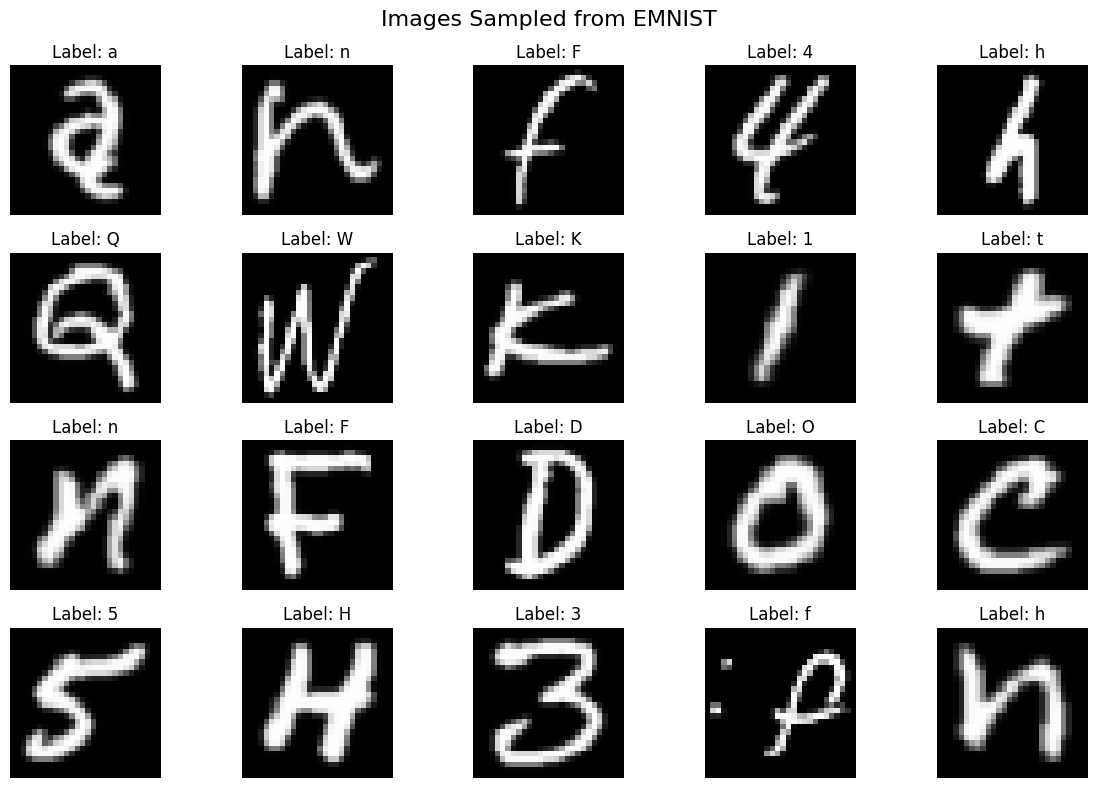

In [ ]:
fig = plt.figure(figsize=(12, 8))
for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f'Label: {mapping_dict[y_train[i]]}')
    plt.axis('off')
plt.suptitle('Images Sampled from EMNIST', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# Image Preprocessing
print("Original data shapes:")
print(f"x_train: {x_train.shape}, x_test: {x_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")
print(f"Pixel value range: {x_train.min()} to {x_train.max()}")

# 1. Normalization: Scale pixel values to [0, 1] range
# Formula: I_norm = I/255
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

print(f"\nAfter normalization:")
print(f"Pixel value range: {x_train_norm.min()} to {x_train_norm.max()}")

# 2. Reshaping for CNN input: Add channel dimension
# From (28, 28) to (28, 28, 1)
x_train_reshaped = x_train_norm.reshape(x_train_norm.shape[0], 28, 28, 1)
x_test_reshaped = x_test_norm.reshape(x_test_norm.shape[0], 28, 28, 1)

print(f"\nAfter reshaping:")
print(f"x_train: {x_train_reshaped.shape}, x_test: {x_test_reshaped.shape}")

# 3. Label encoding: Convert to one-hot encoded vectors
y_train_onehot = keras.utils.to_categorical(y_train, num_classes)
y_test_onehot = keras.utils.to_categorical(y_test, num_classes)

print(f"\nAfter one-hot encoding:")
print(f"y_train: {y_train_onehot.shape}, y_test: {y_test_onehot.shape}")

print(f"\nExample label before: {y_train[0]}")
print(f"Example label after: {y_train_onehot[0]}")

# Store preprocessed data
x_train_processed = x_train_reshaped
x_test_processed = x_test_reshaped
y_train_processed = y_train_onehot
y_test_processed = y_test_onehot

Original data shapes:
x_train: (112799, 28, 28), x_test: (18799, 28, 28)
y_train: (112799,), y_test: (18799,)
Pixel value range: 0 to 255

After normalization:
Pixel value range: 0.0 to 1.0

After reshaping:
x_train: (112799, 28, 28, 1), x_test: (18799, 28, 28, 1)

After one-hot encoding:
y_train: (112799, 47), y_test: (18799, 47)

Example label before: 36
Example label after: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


Nos separamos un pedacito de los datos de entrenamiento para validación.

La función de `tensorflow.keras.model.fit()` permite un parámetro de `validation_split` y otro de `validation_data`. El primero nos deja poner un porcentaje (e.g. 0.2) para separar, ¿Por qué no lo usamos? (tip: lea la documentación).

In [ ]:
# Select validation indices (balanced according to available classes)
x_train_processed, x_val_processed, y_train_processed, y_val_processed = \
    train_test_split(x_train_processed, y_train_processed, test_size=0.1, stratify=y_train)

# Make sure data is all there
assert(x_train_processed.shape[0] + x_val_processed.shape[0] == x_train.shape[0])
assert(y_train_processed.shape[0] + y_val_processed.shape[0] == y_train.shape[0])

# Parte 2 - Modelo
Armaremos una arquitectura de red profunda convolucional (CNN) para clasificar los distintos caracteres.

Construiremos la siguiente arquitectura (arbitraria):
((TODO: traducir del ingles!))

* Input Layer: Shape (28, 28, 1) for grayscale images
* Layer 1: Conv2D with 32 filters, 3x3 kernel, ReLU activation
* Layer 2: MaxPooling2D with 2x2 pool size
* Layer 3: Conv2D with 64 filters, 3x3 kernel, ReLU activation
* Layer 4: MaxPooling2D with 2x2 pool size
* Layer 5: Flatten layer (this will serve as feature extractor)
* Layer 6: Dense layer with 128 units, ReLU activation
* Layer 7: Output Dense layer with num_classes units, Softmax activation

The Flatten layer output will be used as feature vectors for correlation-based classification.

In [ ]:
def create_cnn_model(input_shape=(28, 28, 1), num_classes=47):
    model = keras.Sequential([
        # Input Layer
        keras.Input(shape=input_shape),

        # Layer 1: Conv2D with 32 filters, 3x3 kernel, ReLU activation
        layers.Conv2D(32, (3, 3), activation='relu', padding='valid', name='conv2d_1'),

        # Layer 2: MaxPooling2D with 2x2 pool size
        layers.MaxPooling2D((2, 2), name='maxpool2d_1'),

        # Layer 3: Conv2D with 64 filters, 3x3 kernel, ReLU activation
        layers.Conv2D(64, (3, 3), activation='relu', padding='valid', name='conv2d_2'),

        # Layer 4: MaxPooling2D with 2x2 pool size
        layers.MaxPooling2D((2, 2), name='maxpool2d_2'),

        # Layer 5: Flatten layer (feature extractor)
        layers.Flatten(name='flatten'),

        # Layer 6: Dense layer with 128 units, ReLU activation
        layers.Dense(128, activation='relu', name='dense_1'),

        # Layer 7: Output Dense layer with enough classes for alphanumeric characters
        layers.Dense(num_classes, activation='softmax', name='output')
    ], name='lccEMNIST')

    return model


cnn_model = create_cnn_model()
cnn_model.summary()

Model: "lccEMNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 47)             │         6,063 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 229,807 (897.68 KB)

 Trainable params: 229,807 (897.68 KB)

 Non-trainable params: 0 (0.00 B)

# Parte 3 - Métricas y Optimizadores

...

In [ ]:
# # Creamos un optimizador
optimizer = keras.optimizers.Adam(
    learning_rate=0.001
)

# Elegimos una métrica de error
loss = keras.losses.CategoricalCrossentropy()

# Elegimos métricas para calcular paso a paso
metrics = [
    keras.metrics.Accuracy(),
    keras.metrics.BinaryAccuracy(),
    keras.metrics.CategoricalAccuracy(),
    keras.metrics.CategoricalCrossentropy()
]

# Compile the CNN model
cnn_model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=metrics
)

# Parte 4 - Entrenamiento

...

In [ ]:
# Corremos el entrenamiento del modelo con batches de 16 imágenes
# y una cantidad arbitraria de épocas.
print("\nStarting CNN training...")
history = cnn_model.fit(
    x_train_processed, y_train_processed,
    batch_size=16,
    epochs=50,
    validation_data=(x_val_processed, y_val_processed),
    verbose=1,
)
print("\nCNN training completed!")

# Guarda toda la información del modelo, incluyendo pesos, y
# luego pueden hacer `keras.models.load_model(...)` para cargarlo
# cnn_model.save()



Starting CNN training...
Epoch 1/50
6345/6345 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.0000e+00 - binary_accuracy: 0.9896 - categorical_accuracy: 0.7092 - categorical_crossentropy: 0.9685 - loss: 0.9685 - val_accuracy: 0.0000e+00 - val_binary_accuracy: 0.9938 - val_categorical_accuracy: 0.8465 - val_categorical_crossentropy: 0.4471 - val_loss: 0.4471
Epoch 2/50
6345/6345 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - accuracy: 8.1063e-08 - binary_accuracy: 0.9944 - categorical_accuracy: 0.8630 - categorical_crossentropy: 0.3849 - loss: 0.3849 - val_accuracy: 0.0000e+00 - val_binary_accuracy: 0.9942 - val_categorical_accuracy: 0.8588 - val_categorical_crossentropy: 0.3920 - val_loss: 0.3920
Epoch 3/50
6345/6345 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - accuracy: 5.8614e-07 - binary_accuracy: 0.9952 - categorical_accuracy: 0.8841 - categorical_crossentropy: 0.3229 - loss: 0.3229 - val_accuracy: 0.0000e+00 - val_binary_accuracy: 0.9946 - val_categorical_accuracy: 0.8699 - val_categorical_crossentr

Cuando guardamos el modelo con `.save()` estamos guardando todo lo siguiente:

* La arquitectura y configuración del modelo
* Los pesos del modelo aprendidos durante entrenamiento
* La información pasada al compilar el modelo (si se usó `compile()`)
* El optimizador y su estado actual (esto les permitirá reiniciar el entrenamiento si se corta o si quieren continuarlo)

Hay que tenerlo en cuenta, ya que a veces se puede querer guardar solo la configuración y no los pesos. O podemos pensar que empezamos a entrenar una red de cero pero cargamos los pesos de algo ya entrenado.

> **OJO!**: en Google Colab deben tener montada una carpeta de Google Drive, sinó lo guardará en el disco local a la sesión (y se borrará si se cae la sesión).
O pueden usar `from google.colab import files ; files.download(...)` para descargar algo del entorno local a su PC.

También pueden usar un ModelCheckpoint para que les guarde la mejor red en validación: https://www.tensorflow.org/guide/keras/training_with_built_in_methods#checkpointing_models




Miremos cómo le fue al entrenamiento

In [ ]:
print(history.history.keys())

dict_keys(['accuracy', 'binary_accuracy', 'categorical_accuracy', 'categorical_crossentropy', 'loss', 'val_accuracy', 'val_binary_accuracy', 'val_categorical_accuracy', 'val_categorical_crossentropy', 'val_loss'])


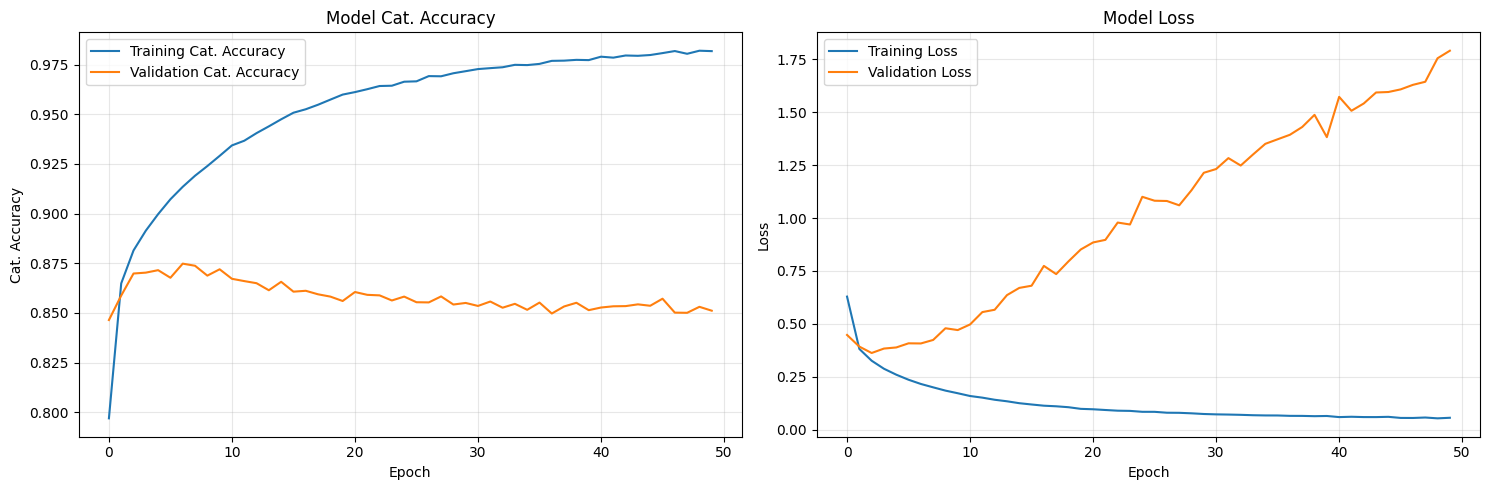

Final Training Results:
Training Accuracy: 0.9817
Validation Accuracy: 0.8512
Training Loss: 0.0555
Validation Loss: 1.7910


In [ ]:
def plot_history_graphics(history):
    fig = plt.figure(figsize=(15, 5))

    # Plot training & validation accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['categorical_accuracy'], label='Training Cat. Accuracy')
    plt.plot(history.history['val_categorical_accuracy'], label='Validation Cat. Accuracy')
    plt.title('Model Cat. Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Cat. Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot training & validation loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print final training results
    print("Final Training Results:")
    print(f"Training Accuracy: {history.history['categorical_accuracy'][-1]:.4f}")
    print(f"Validation Accuracy: {history.history['val_categorical_accuracy'][-1]:.4f}")
    print(f"Training Loss: {history.history['loss'][-1]:.4f}")
    print(f"Validation Loss: {history.history['val_loss'][-1]:.4f}")
    print("")
    print(f"Best Validation Accuracy: {max(history.history['val_categorical_accuracy']):.4f}")
    print(f"Best Validation Loss: {min(history.history['val_loss']):.4f}")

plot_history_graphics(history)

# Parte 5 - Evaluación

In [ ]:
# Get CNN predictions on test set
cnn_predictions = cnn_model.predict(x_test_processed, batch_size=32, verbose=1)
cnn_predicted_classes = np.argmax(cnn_predictions, axis=1)

# Calculate CNN metrics
cnn_correct_predictions = np.sum(cnn_predicted_classes == y_test)
cnn_accuracy = cnn_correct_predictions / len(y_test)
cnn_error_rate = 1 - cnn_accuracy

print(f"\nStandalone CNN Results:")
print(f"Correct predictions: {cnn_correct_predictions}/{len(y_test)}")
print(f"Accuracy: {cnn_accuracy:.4f} ({cnn_accuracy*100:.2f}%)")
print(f"Error Rate: {cnn_error_rate:.4f} ({cnn_error_rate*100:.2f}%)")

588/588 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

Standalone CNN Results:
Correct predictions: 16039/18799
Accuracy: 0.8532 (85.32%)
Error Rate: 0.1468 (14.68%)


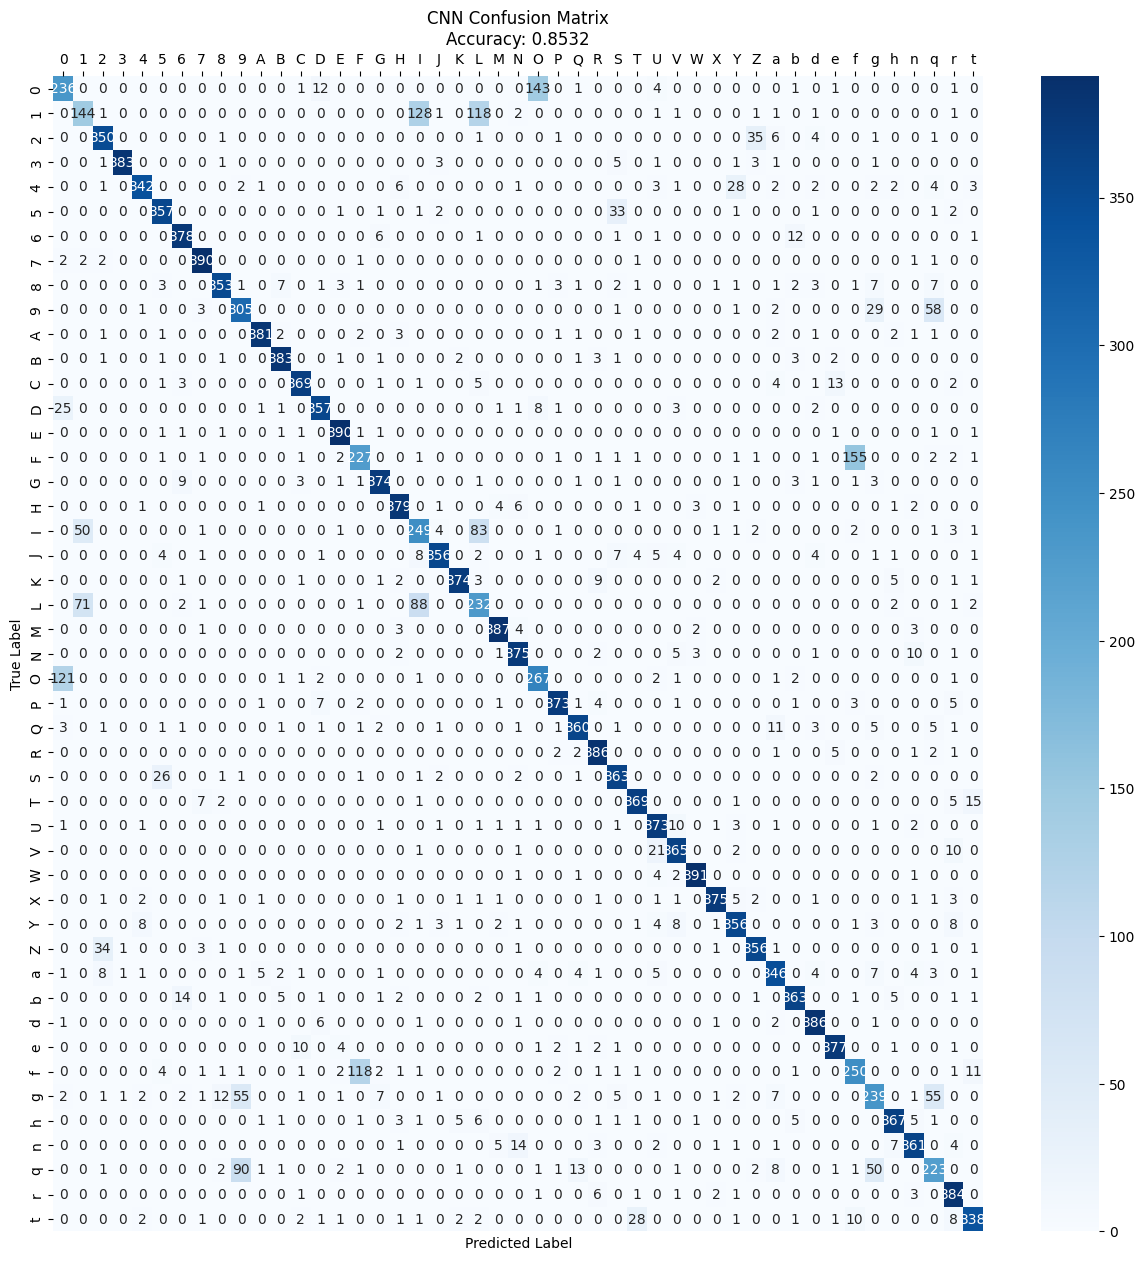

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cnn_cm = confusion_matrix(y_test, cnn_predicted_classes)

# CNN Confusion Matrix
plt.figure(figsize=(15, 15))
sns.heatmap(cnn_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=mapping_dict.values(), yticklabels=mapping_dict.values())
plt.gca().tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
plt.title(f'CNN Confusion Matrix\nAccuracy: {cnn_accuracy:.4f}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()



# Parte 6 - Regularización y Data Augmentation


Miramos cómo quedan las imágenes aumentadas con transformaciones afines: rotaciones, zooms, translaciones

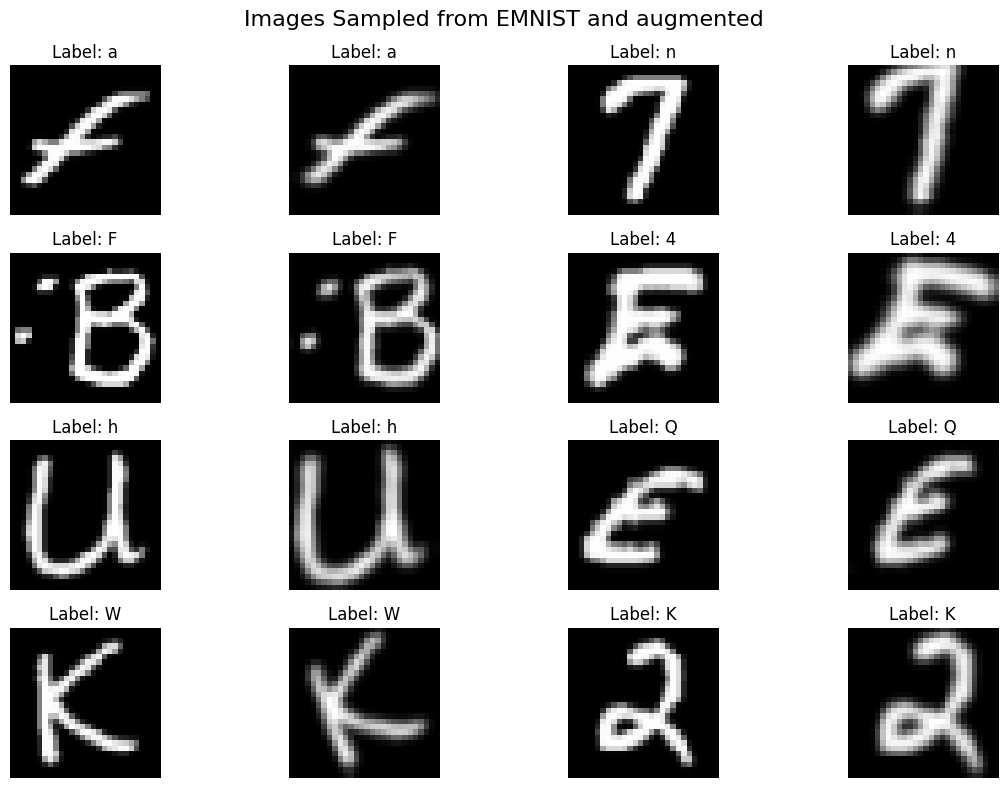

In [ ]:
data_augmentation_single = keras.Sequential(
    [
        layers.RandomRotation(0.05),          # Random rotation by up to 5% of 2*pi
        layers.RandomZoom(0.1),               # Random zoom in/out by up to 10%
        layers.RandomTranslation(0.05, 0.05), # Random translation by up to 5% of image width/height
    ]
)

fig = plt.figure(figsize=(12, 8))
for i in range(8):
    plt.subplot(4, 4, 2*i + 1)
    plt.imshow(x_train_processed[i], cmap='gray')
    plt.title(f'Label: {mapping_dict[y_train[i]]}')
    plt.axis('off')
    plt.subplot(4, 4, 2*i + 2)
    x_train_augmented = data_augmentation_single(x_train_processed[i])
    plt.imshow(x_train_augmented, cmap='gray')
    plt.title(f'Label: {mapping_dict[y_train[i]]}')
    plt.axis('off')
plt.suptitle('Images Sampled from EMNIST and augmented', fontsize=16)
plt.tight_layout()
plt.show()

Testeamos añadir ambos aumentación de datos y dropout.

In [ ]:
def create_cnn_model2(input_shape=(28, 28, 1), num_classes=47):
    data_augmentation = keras.Sequential(
        [
            keras.Input(shape=(28, 28, 1)),
            layers.RandomRotation(0.05),          # Random rotation by up to 5% of 2*pi
            layers.RandomZoom(0.1),               # Random zoom in/out by up to 10%
            layers.RandomTranslation(0.05, 0.05), # Random translation by up to 5% of image width/height
        ], name='augmentation'
    )

    model = keras.Sequential([
        # Input Layer
        keras.Input(shape=input_shape),

        # Data Augmentation (defined above)
        data_augmentation,

        # Layer 1: Conv2D with 32 filters, 3x3 kernel, ReLU activation
        layers.Conv2D(32, (3, 3), activation='relu', padding='valid', name='conv2d_1'),

        # Layer 2: MaxPooling2D with 2x2 pool size
        layers.MaxPooling2D((2, 2), name='maxpool2d_1'),

        # Layer 3: Conv2D with 64 filters, 3x3 kernel, ReLU activation
        layers.Conv2D(64, (3, 3), activation='relu', padding='valid', name='conv2d_2'),

        # Layer 4: MaxPooling2D with 2x2 pool size
        layers.MaxPooling2D((2, 2), name='maxpool2d_2'),

        # Layer 5: Flatten layer (feature extractor)
        layers.Flatten(name='flatten'),

        # Layer 6: Dropout layer (20% chance)
        layers.Dropout(0.3, name='dropout_1'),

        # Layer 7: Dense layer with 128 units, ReLU activation
        layers.Dense(128, activation='relu', name='dense_1'),

        layers.Dropout(0.3, name='dropout_2'),

        # Layer 8: Output Dense layer with enough classes for alphanumeric characters
        layers.Dense(num_classes, activation='softmax', name='output')
    ], name='lccEMNIST_reg')

    return model


cnn_model2 = create_cnn_model2()
cnn_model2.summary()

Model: "lccEMNIST_reg"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 47)             │         6,063 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 229,807 (897.68 KB)

 Trainable params: 229,807 (897.68 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = keras.optimizers.Adam(
    learning_rate=0.0001
)

loss = keras.losses.CategoricalCrossentropy()

metrics = [
    keras.metrics.Accuracy(),
    keras.metrics.BinaryAccuracy(),
    keras.metrics.CategoricalAccuracy(),
    keras.metrics.CategoricalCrossentropy()
]

cnn_model2.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=metrics
)

print("\nStarting CNN training...")
history = cnn_model2.fit(
    x_train_processed, y_train_processed,
    batch_size=16,
    epochs=50,
    validation_data=(x_val_processed, y_val_processed),
    verbose=1,
)
print("\nCNN training completed!")


Starting CNN training...
Epoch 1/50
5640/5640 ━━━━━━━━━━━━━━━━━━━━ 55s 9ms/step - accuracy: 0.0000e+00 - binary_accuracy: 0.9800 - categorical_accuracy: 0.2873 - categorical_crossentropy: 2.6735 - loss: 2.6735 - val_accuracy: 0.0000e+00 - val_binary_accuracy: 0.9905 - val_categorical_accuracy: 0.7644 - val_categorical_crossentropy: 0.7611 - val_loss: 0.7611
Epoch 2/50
5640/5640 ━━━━━━━━━━━━━━━━━━━━ 79s 9ms/step - accuracy: 0.0000e+00 - binary_accuracy: 0.9858 - categorical_accuracy: 0.6206 - categorical_crossentropy: 1.2485 - loss: 1.2485 - val_accuracy: 0.0000e+00 - val_binary_accuracy: 0.9923 - val_categorical_accuracy: 0.8094 - val_categorical_crossentropy: 0.5696 - val_loss: 0.5696
Epoch 3/50
5640/5640 ━━━━━━━━━━━━━━━━━━━━ 49s 9ms/step - accuracy: 0.0000e+00 - binary_accuracy: 0.9881 - categorical_accuracy: 0.6939 - categorical_crossentropy: 0.9703 - loss: 0.9703 - val_accuracy: 0.0000e+00 - val_binary_accuracy: 0.9928 - val_categorical_accuracy: 0.8246 - val_categorical_crossentr

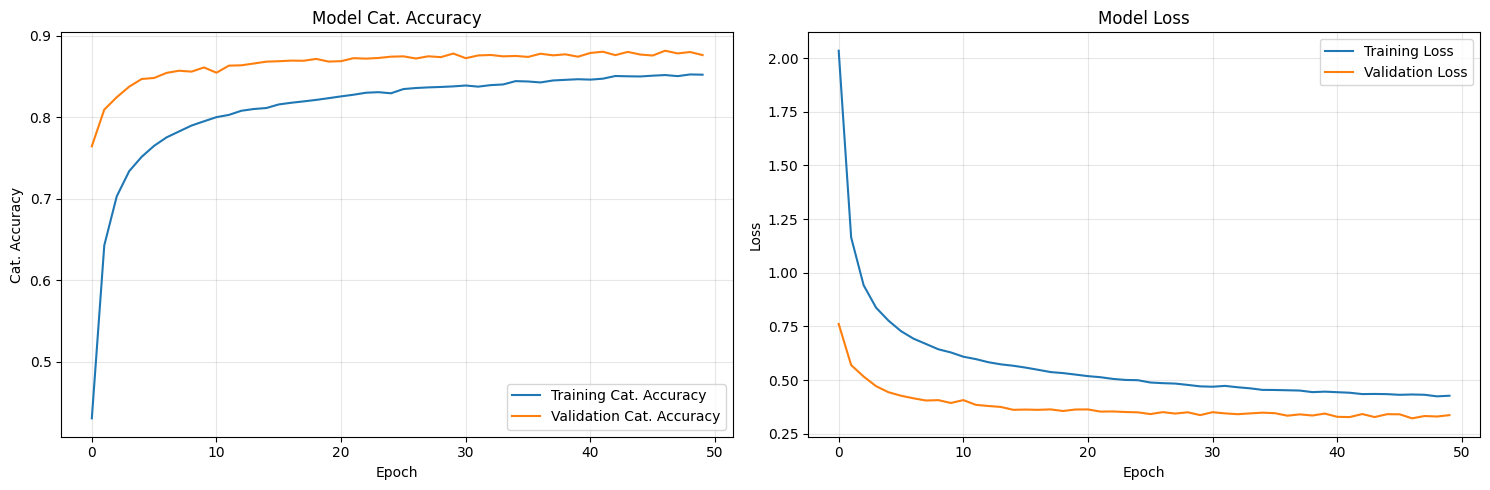

Final Training Results:
Training Accuracy: 0.8522
Validation Accuracy: 0.8763
Training Loss: 0.4268
Validation Loss: 0.3364


In [ ]:
plot_history_graphics(history)

Intentamos agregando Adam con Weight Decay (AdamW)

In [ ]:
cnn_model3 = create_cnn_model2()
cnn_model3.name = "lccEMNIST_regw"
cnn_model3.summary()

Model: "lccEMNIST_regw"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 47)             │         6,063 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 229,807 (897.68 KB)

 Trainable params: 229,807 (897.68 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = keras.optimizers.AdamW(
    learning_rate=0.0001
)

loss = keras.losses.CategoricalCrossentropy()

metrics = [
    keras.metrics.Accuracy(),
    keras.metrics.BinaryAccuracy(),
    keras.metrics.CategoricalAccuracy(),
    keras.metrics.CategoricalCrossentropy()
]

cnn_model3.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=metrics
)

print("\nStarting CNN training...")
history = cnn_model3.fit(
    x_train_processed, y_train_processed,
    batch_size=16,
    epochs=50,
    validation_data=(x_val_processed, y_val_processed),
    verbose=1,
)
print("\nCNN training completed!")


Starting CNN training...
Epoch 1/50
6345/6345 ━━━━━━━━━━━━━━━━━━━━ 65s 9ms/step - accuracy: 0.0000e+00 - binary_accuracy: 0.9803 - categorical_accuracy: 0.3082 - categorical_crossentropy: 2.5860 - loss: 2.5860 - val_accuracy: 0.0000e+00 - val_binary_accuracy: 0.9910 - val_categorical_accuracy: 0.7699 - val_categorical_crossentropy: 0.7265 - val_loss: 0.7265
Epoch 2/50
6345/6345 ━━━━━━━━━━━━━━━━━━━━ 58s 9ms/step - accuracy: 0.0000e+00 - binary_accuracy: 0.9863 - categorical_accuracy: 0.6373 - categorical_crossentropy: 1.1881 - loss: 1.1881 - val_accuracy: 0.0000e+00 - val_binary_accuracy: 0.9924 - val_categorical_accuracy: 0.8110 - val_categorical_crossentropy: 0.5660 - val_loss: 0.5660
Epoch 3/50
6345/6345 ━━━━━━━━━━━━━━━━━━━━ 82s 9ms/step - accuracy: 0.0000e+00 - binary_accuracy: 0.9886 - categorical_accuracy: 0.7066 - categorical_crossentropy: 0.9348 - loss: 0.9348 - val_accuracy: 0.0000e+00 - val_binary_accuracy: 0.9932 - val_categorical_accuracy: 0.8328 - val_categorical_crossentr

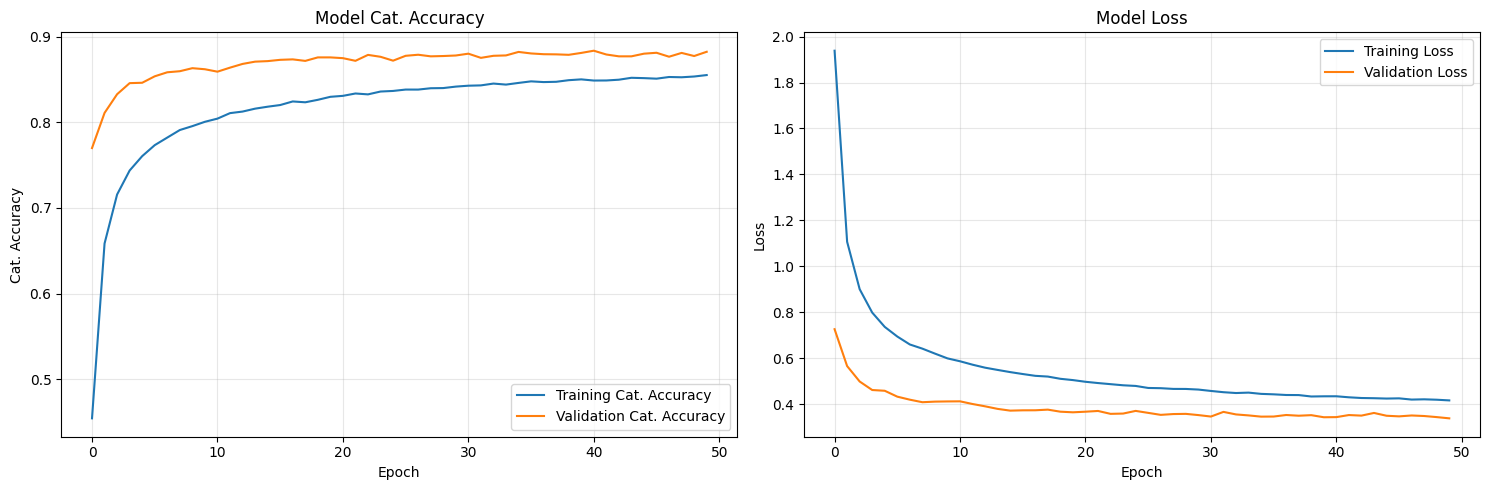

Final Training Results:
Training Accuracy: 0.8552
Validation Accuracy: 0.8824
Training Loss: 0.4166
Validation Loss: 0.3385


In [ ]:
plot_history_graphics(history)

In [ ]:
# Get CNN predictions on test set
cnn_predictions = cnn_model3.predict(x_test_processed, batch_size=32, verbose=1)
cnn_predicted_classes = np.argmax(cnn_predictions, axis=1)

# Calculate CNN metrics
cnn_correct_predictions = np.sum(cnn_predicted_classes == y_test)
cnn_accuracy = cnn_correct_predictions / len(y_test)
cnn_error_rate = 1 - cnn_accuracy

print(f"\nStandalone CNN Results:")
print(f"Correct predictions: {cnn_correct_predictions}/{len(y_test)}")
print(f"Accuracy: {cnn_accuracy:.4f} ({cnn_accuracy*100:.2f}%)")
print(f"Error Rate: {cnn_error_rate:.4f} ({cnn_error_rate*100:.2f}%)")

588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Standalone CNN Results:
Correct predictions: 16567/18799
Accuracy: 0.8813 (88.13%)
Error Rate: 0.1187 (11.87%)
